# Librerias

In [15]:
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import wordnet as wn
import gensim.downloader as api
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
try:
    nltk.data.find("corpora/wordnet")
except LookupError:
    nltk.download("wordnet")

try:
    nltk.data.find("corpora/omw-1.4")
except LookupError:
    nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ENRIQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ENRIQUE\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Carga de Datasets 

In [3]:
MC_PATH = r"D:\Ciencia de Datos\8vo\PLN_Avanzado\Practicas\Practica2\MC30.csv"
WS_PATH = r"D:\Ciencia de Datos\8vo\PLN_Avanzado\Practicas\Practica2\WS353.csv"

OUT_DIR = r"."

In [4]:
mc = pd.read_csv(MC_PATH, sep=";")
ws = pd.read_csv(WS_PATH, sep=";")

# Funciones auxiliares 

In [5]:
def cosine(u, v, eps=1e-12):
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return float(np.dot(u, v) / ((np.linalg.norm(u) * np.linalg.norm(v)) + eps))

def pearson_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 2:
        return np.nan, int(m.sum())
    return float(np.corrcoef(x[m], y[m])[0, 1]), int(m.sum())

# Parte 1: Similitud usando WordNet

In [6]:
def synsets_by_pos(word, allowed_pos=("n", "v")):
    """Synsets filtrados por POS (n=noun, v=verb)."""
    return [s for s in wn.synsets(word) if s.pos() in allowed_pos]

def max_pairwise_similarity(word1, word2, sim_fn, allowed_pos=("n","v")):
    """
    WSD por máximo entre sentidos:
    max_{s1 in Syn(word1), s2 in Syn(word2)} sim(s1,s2),
    restringiendo a mismo POS y allowed_pos.
    """
    s1_list = synsets_by_pos(word1, allowed_pos=allowed_pos)
    s2_list = synsets_by_pos(word2, allowed_pos=allowed_pos)

    best = None
    for s1 in s1_list:
        for s2 in s2_list:
            if s1.pos() != s2.pos():
                continue
            try:
                val = sim_fn(s1, s2)
            except Exception:
                val = None
            if val is None:
                continue
            if (best is None) or (val > best):
                best = val
    return best

def path_sim(s1, s2):
    return s1.path_similarity(s2)

def wup_sim(s1, s2):
    return s1.wup_similarity(s2)

def lch_sim(s1, s2):
    # LCH requiere misma taxonomía y profundidad válida
    return s1.lch_similarity(s2)

def compute_wordnet_metrics(df, col_w1="EN.1", col_w2="EN.2"):
    out = df.copy()
    out["path_max"] = [
        max_pairwise_similarity(w1, w2, path_sim, allowed_pos=("n","v"))
        for w1, w2 in zip(out[col_w1], out[col_w2])
    ]
    out["wup_max"] = [
        max_pairwise_similarity(w1, w2, wup_sim, allowed_pos=("n","v"))
        for w1, w2 in zip(out[col_w1], out[col_w2])
    ]
    out["lch_max"] = [
        max_pairwise_similarity(w1, w2, lch_sim, allowed_pos=("n","v"))
        for w1, w2 in zip(out[col_w1], out[col_w2])
    ]
    return out

In [7]:
mc_wn = compute_wordnet_metrics(mc, "EN.1", "EN.2")
ws_wn = compute_wordnet_metrics(ws, "EN.1", "EN.2")

# Parte 2: Similitud usando modelos de vectores (Embeddings)

In [8]:
print("Cargando los modelos de embeddings pre-entrenados")

# FastText 
fasttext = api.load("fasttext-wiki-news-subwords-300")
print("fastText loaded:", len(fasttext), "dim:", fasttext.vector_size)

# GloVe
glove = api.load("glove-wiki-gigaword-50")
print("GloVe loaded:", len(glove), "dim:", glove.vector_size)

def get_vec_gensim(model, word):
    """
    Extrae vector. Intentamos:
    - palabra tal cual
    - lower()
    - (opcional) capitalized() si fuera necesario
    """
    w = str(word).strip()
    if w in model:
        return model[w]
    wlow = w.lower()
    if wlow in model:
        return model[wlow]
    wcap = w.capitalize()
    if wcap in model:
        return model[wcap]
    return None

def cos_model(model, w1, w2):
    v1 = get_vec_gensim(model, w1)
    v2 = get_vec_gensim(model, w2)
    if v1 is None or v2 is None:
        return np.nan
    # Con gensim puedes usar similarity, pero aquí lo dejamos uniforme:
    return cosine(v1, v2)

def compute_embedding_metrics(df, col_w1="EN.1", col_w2="EN.2"):
    out = df.copy()
    out["cos_fasttext"] = [cos_model(fasttext, a, b) for a, b in zip(out[col_w1], out[col_w2])]
    out["cos_glove50"]  = [cos_model(glove,    a, b) for a, b in zip(out[col_w1], out[col_w2])]
    return out

Cargando los modelos de embeddings pre-entrenados
fastText loaded: 999999 dim: 300
GloVe loaded: 400000 dim: 50


In [9]:
mc_emb = compute_embedding_metrics(mc, "EN.1", "EN.2")
ws_emb = compute_embedding_metrics(ws, "EN.1", "EN.2")

In [10]:
# Guardar resultados intermedios
mc_wn.to_csv(f"{OUT_DIR}/MC30_wordnet_sim.csv", index=False)
ws_wn.to_csv(f"{OUT_DIR}/WS353_wordnet_sim.csv", index=False)
mc_emb.to_csv(f"{OUT_DIR}/MC30_embeddings_cosine.csv", index=False)
ws_emb.to_csv(f"{OUT_DIR}/WS353_embeddings_cosine.csv", index=False)

print("Guardado en: MC30_wordnet_sim.csv, WS353_wordnet_sim.csv")
print("Guardado en: MC30_embeddings_cosine.csv, WS353_embeddings_cosine.csv")

Guardado en: MC30_wordnet_sim.csv, WS353_wordnet_sim.csv
Guardado en: MC30_embeddings_cosine.csv, WS353_embeddings_cosine.csv


# Evaluacion 

In [11]:
keys = ["EN.1", "EN.2", "score"]
mc_all = mc_wn.merge(mc_emb, on=keys, how="inner")
ws_all = ws_wn.merge(ws_emb, on=keys, how="inner")

# Métodos a evaluar
wordnet_cols = ["path_max", "wup_max", "lch_max"]
embed_cols   = ["cos_fasttext", "cos_glove50"]
all_methods  = wordnet_cols + embed_cols

rows = []
for df, dataset_name in [(mc_all, "MC30"), (ws_all, "WS353")]:
    for m in all_methods:
        r, n = pearson_corr(df[m], df["score"])
        rows.append({"dataset": dataset_name, "method": m, "pearson_r": r, "n": n})

eval_all = pd.DataFrame(rows).sort_values(["dataset", "method"]).reset_index(drop=True)
eval_all.to_csv(f"{OUT_DIR}/Evaluacion_Pearson_TODOS.csv", index=False)

print("\nGuardado en: Evaluacion_Pearson_TODOS.csv")
print(eval_all)



Guardado en: Evaluacion_Pearson_TODOS.csv
  dataset        method  pearson_r    n
0    MC30  cos_fasttext   0.852626   30
1    MC30   cos_glove50   0.481947   30
2    MC30       lch_max   0.779165   30
3    MC30      path_max   0.752251   30
4    MC30       wup_max   0.778215   30
5   WS353  cos_fasttext   0.695758  352
6   WS353   cos_glove50   0.502821  352
7   WS353       lch_max   0.347827  350
8   WS353      path_max   0.378760  350
9   WS353       wup_max   0.309326  350


In [12]:
# 20 pares
mc_all.to_csv(f"{OUT_DIR}/MC30_resultados_finales.csv", index=False)
ws_all.to_csv(f"{OUT_DIR}/WS353_resultados_finales.csv", index=False)

print("\nGuardado en: MC30_resultados_finales.csv, WS353_resultados_finales.csv")
cols_pdf = ["EN.1", "EN.2", "score"] + all_methods

tabla20_mc = mc_all[cols_pdf].head(20)
tabla20_ws = ws_all[cols_pdf].head(20)

tabla20_mc.to_csv(f"{OUT_DIR}/Tabla20_MC30.csv", index=False)
tabla20_ws.to_csv(f"{OUT_DIR}/Tabla20_WS353.csv", index=False)

print("\nGuardado en: Tabla20_MC30.csv, Tabla20_WS353.csv")
print("\nPreview de Tabla20_MC30:")
print(tabla20_mc)


Guardado en: MC30_resultados_finales.csv, WS353_resultados_finales.csv

Guardado en: Tabla20_MC30.csv, Tabla20_WS353.csv

Preview de Tabla20_MC30:
        EN.1        EN.2  score  path_max   wup_max   lch_max  cos_fasttext  \
0     asylum    madhouse   3.61  0.500000  0.952381  2.944439      0.500166   
1       bird        cock   3.05  0.500000  0.952381  2.944439      0.563235   
2       bird       crane   2.97  0.250000  0.869565  2.251292      0.584325   
3        boy         lad   3.76  0.500000  0.947368  2.944439      0.735316   
4    brother        monk   2.82  0.500000  0.952381  2.944439      0.470242   
5        car  automobile   3.92  1.000000  1.000000  3.637586      0.779027   
6   cemetery    woodland   0.95  0.111111  0.428571  1.440362      0.488168   
7      chord       smile   0.13  0.125000  0.375000  1.239691      0.238892   
8      coast      forest   0.42  0.166667  0.545455  1.845827      0.442574   
9      coast        hill   0.87  0.200000  0.666667  2.028148 

In [16]:
EVAL_PATH = Path("Evaluacion_Pearson_TODOS.csv")

eval_df = pd.read_csv(EVAL_PATH)
MC_ALL = pd.read_csv("Tabla20_MC30.csv")
WS_ALL = pd.read_csv("Tabla20_WS353.csv")
methods = ["path_max","wup_max","lch_max","cos_fasttext","cos_glove50"]


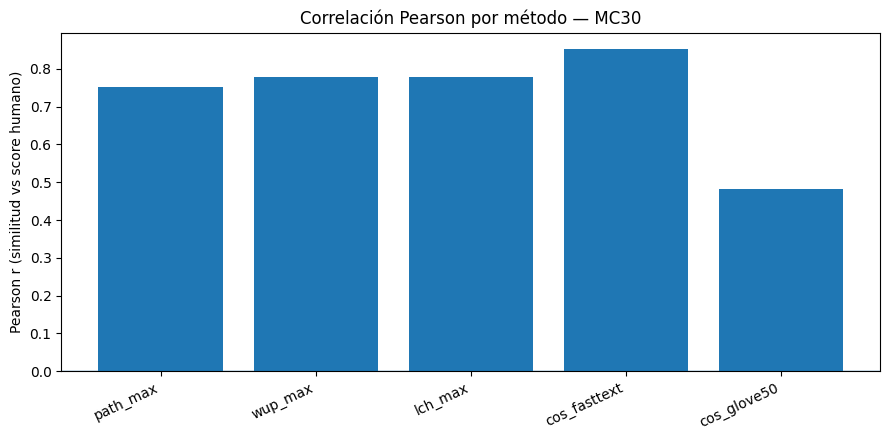

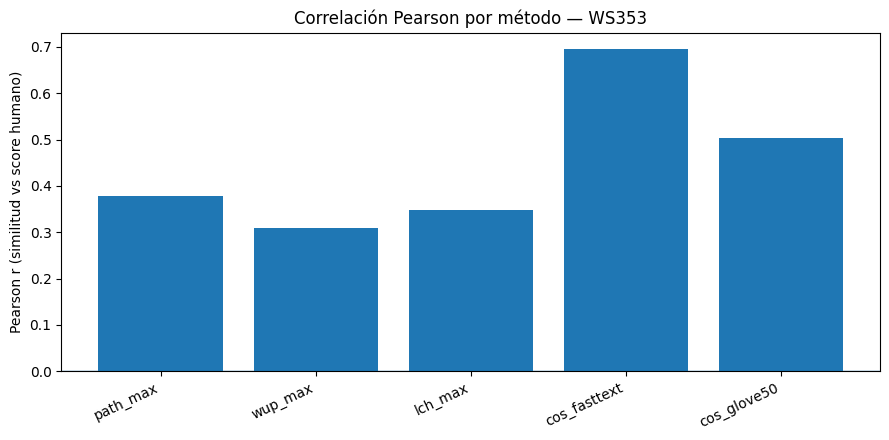

In [ ]:
def plot_pearson_bars(eval_df, dataset, save_as=None):
    df = eval_df[eval_df["dataset"] == dataset].copy()
    order = ["path_max","wup_max","lch_max","cos_fasttext","cos_glove50"]
    df["method"] = pd.Categorical(df["method"], categories=order, ordered=True)
    df = df.sort_values("method")

    x = np.arange(len(df))
    y = df["pearson_r"].astype(float).values

    plt.figure(figsize=(9,4.5))
    plt.bar(x, y)
    plt.axhline(0, linewidth=1)
    plt.xticks(x, df["method"], rotation=25, ha="right")
    plt.ylabel("Pearson r (similitud vs score humano)")
    plt.title(f"Correlación Pearson por método — {dataset}")
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=200, bbox_inches="tight")
    plt.show()

plot_pearson_bars(eval_df, "MC30", save_as="pearson_bar_MC30.png")
plot_pearson_bars(eval_df, "WS353", save_as="pearson_bar_WS353.png")


In [18]:
df20 = pd.read_csv("Tabla20_WS353.csv")  

methods = ["path_max","wup_max","lch_max","cos_fasttext","cos_glove50"]


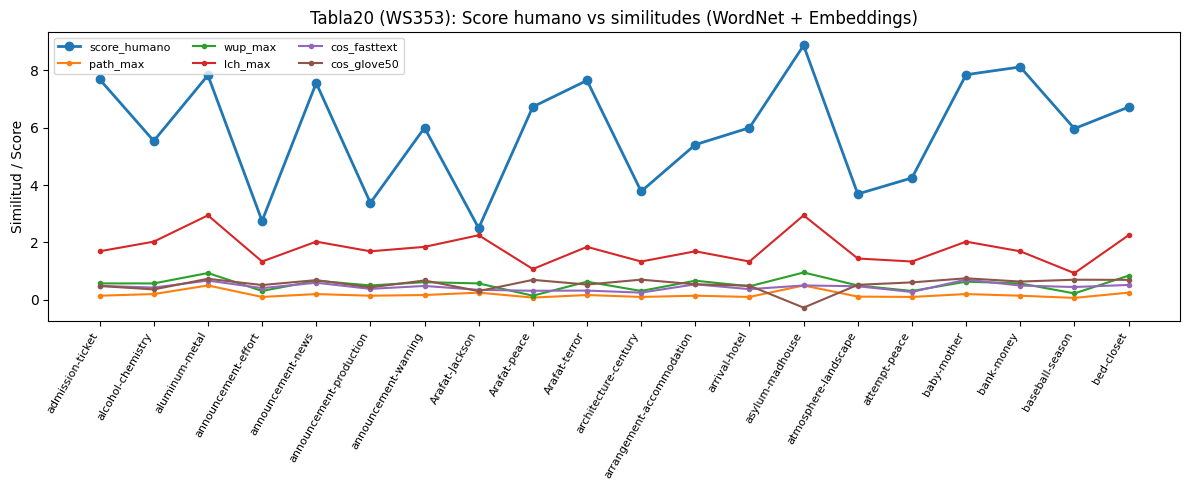

In [ ]:
def plot_table20_lines(df20, methods, title="Tabla20: Score humano vs métodos", save_as=None):
    df = df20.copy()

    # etiqueta del par: "word1–word2"
    pair_labels = [f"{a}-{b}" for a,b in zip(df["EN.1"], df["EN.2"])]
    x = np.arange(len(df))

    plt.figure(figsize=(12,5))

    # Score humano
    plt.plot(x, df["score"].astype(float).values, marker="o", linewidth=2, label="score_humano")

    # Métodos
    for m in methods:
        y = df[m].astype(float).values
        plt.plot(x, y, marker=".", linewidth=1.5, label=m)

    plt.xticks(x, pair_labels, rotation=60, ha="right", fontsize=8)
    plt.ylabel("Similitud / Score")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as, dpi=200, bbox_inches="tight")
    plt.show()

plot_table20_lines(
    df20, methods,
    title="Tabla20 (WS353): Score humano vs similitudes (WordNet + Embeddings)",
    save_as="tabla20_lines_WS353.png"
)
